In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
valid_labels = pd.read_csv('../../../results/PlantCAD2_tasks/exp-leaf-abs/valid.tsv', sep='\t')
test_labels = pd.read_csv('../../../results/PlantCAD2_tasks/exp-leaf-abs/test.tsv', sep='\t')

In [3]:
model_dict = [
    ('pcv2_1', 'pcv2-l24-d0768-checkpoints-lr-1e-4'),
    ('pcv2_2', 'pcv2-l48-d1024-checkpoints-lr-1e-4'),
    ('pcv2_3', 'pcv2-l48-d1536-checkpoints-lr-1e-4'),
    ('agront', 'agront-checkpoints-lr-1e-4'),
    ('sup_pcv2_1', 'sup_pcv2-l24-d0768-checkpoints-lr-1e-4'),
    ('cnn_lstm', 'cnn_lstm'),
]

In [4]:
for model in model_dict:
    curPATH = f'../../../results/PlantCAD2_tasks/exp-leaf-abs/{model[1]}/valid_scores.tsv'
    curPreds = pd.read_csv(curPATH, sep='\t')
    valid_labels[f'{model[0]}'] = curPreds['predicted_value']

In [5]:
for model in model_dict:
    curPATH = f'../../../results/PlantCAD2_tasks/exp-leaf-abs/{model[1]}/predictions.csv'
    curPreds = pd.read_csv(curPATH, sep='\t')
    test_labels[f'{model[0]}'] = curPreds['predicted_value']

In [6]:
valid_labels.head()

,genome,id,seqid,start,end,strand,orthogroup,Label,Seq,pcv2_1,pcv2_2,pcv2_3,agront,sup_pcv2_1,cnn_lstm
0,Tripsacum_zopilotense/DC_05_58_3A,Tz00001aa000064_T001,ctg_684,249462,249463,+,3I82P,0.000000,GATCGATGCCGGCATGCACTGAAACAAGCCACACAGCTGTACCACT...,0.235640,0.236347,0.235921,0.187457,0.451608,0.185001
1,Tripsacum_zopilotense/DC_05_58_3A,Tz00001aa000070_T001,ctg_684,489785,489786,-,3IFKR,0.187757,CAACCGTAGCCTCGGGGACCTCGCCGCCAAGGCCGTCGGGGTCATC...,0.164753,0.149522,0.070809,0.231032,0.047300,0.306294
2,Tripsacum_zopilotense/DC_05_58_3A,Tz00001aa000078_T001,ctg_684,718137,718138,+,3I8Z7,0.234400,CGCATGCATGAGGATTTTCTTGAGTAGCATAGCGATGGATAGCAAC...,0.703352,0.782154,0.786797,0.947094,0.528545,0.626252
3,Tripsacum_zopilotense/DC_05_58_3A,Tz00001aa000086_T001,ctg_1001,1019122,1019123,-,3I3QX,0.155543,TTCACCTCACAGCTTGCTGCACACACCTCACTTCTGACTGTAACCG...,0.115960,0.253161,0.275657,0.388240,0.238749,0.314836
4,Tripsacum_zopilotense/DC_05_58_3A,Tz00001aa000092_T002,ctg_1001,1398337,1398338,+,3IDRG,0.936343,CCATCTGCGTGGCCACCCACACAGTCACACTCCCCTCGGCCTCCCC...,0.496303,0.570585,0.695060,0.442110,0.316844,0.355873


In [7]:
records = []
pcv2_alphas = [0.4, 0.7, 1.0]
for k, model in enumerate(model_dict):
    valid_preds = valid_labels[f'{model[0]}']
    test_preds = test_labels[f'{model[0]}']

    valid_true = valid_labels['Label']
    test_true = test_labels['Label']
    
    scc_valid = valid_labels['Label'].corr(valid_labels[f'{model[0]}'], method='spearman')
    scc_test = test_labels['Label'].corr(test_labels[f'{model[0]}'], method='spearman')

    pcc_valid = valid_labels['Label'].corr(valid_labels[f'{model[0]}'], method='pearson')
    pcc_test = test_labels['Label'].corr(test_labels[f'{model[0]}'], method='pearson')
    

    if 'agront' in model[0].lower():
        color, alpha = 'gray', 1.0
    elif 'sup_pcv2' in model[0].lower():
        color, alpha = 'C1', 1.0
    elif 'cnn' in model[0].lower():
        color, alpha = 'C1', 0.5
    else:
        color, alpha = 'C0', pcv2_alphas[k]

    if 'cnn' in model[0].lower():
        lab = model[0].replace('-imbalance-lr-1e-3', '')
    else:
        lab = model[0].replace('-checkpoints-lr-1e-4', '')

    records.append({
        'model': model[0],
        'label': 'valid',
        'scc': scc_valid,
        'pcc': pcc_valid,
        'color': color,
        'alpha': alpha    })
    records.append({
        'model': model[0],
        'label': 'test',
        'scc': scc_test,
        'pcc': pcc_test,
        'color': color,
        'alpha': alpha    })

In [8]:
df = pd.DataFrame(records)
df.head()

,model,label,scc,pcc,color,alpha
0,pcv2_1,valid,0.577639,0.567761,C0,0.4
1,pcv2_1,test,0.629641,0.605685,C0,0.4
2,pcv2_2,valid,0.624456,0.620015,C0,0.7
3,pcv2_2,test,0.634053,0.616549,C0,0.7
4,pcv2_3,valid,0.629090,0.623772,C0,1.0


In [9]:
df.to_csv('auc_exp-leaf-abs.tsv', sep='\t', index=False)

In [10]:
models = df['model'].unique()
n_models = len(models)

species_order = ['valid', 'test']
n_sp = len(species_order)

bar_w = 0.8 / n_models
x = np.arange(n_sp)

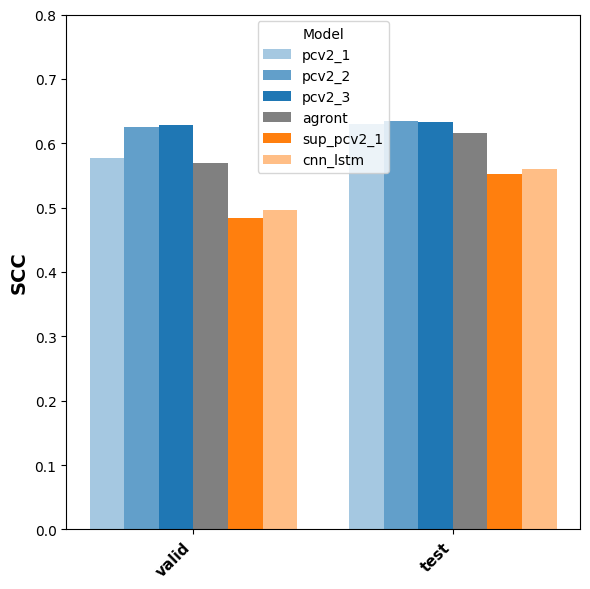

In [11]:
fig, ax = plt.subplots(figsize=(5 + 0.5 * n_sp, 6))

for i, model in enumerate(models):
    sub = df[df['model'] == model]
    sub = sub.set_index('label').reindex(species_order).reset_index()

    ax.bar(
        x + i * bar_w,
        sub['scc'],
        bar_w,
        label=model,
        color=sub['color'].iloc[0] if not sub.empty else 'gray',
        alpha=sub['alpha'].iloc[0] if not sub.empty else 0.5
    )

ax.set_xticks(x + bar_w * (n_models - 1) / 2)
ax.set_xticklabels(species_order, rotation=45, ha='right', fontsize=11, fontweight='bold')

ax.set_ylabel('SCC', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.8)
ax.legend(title='Model', fontsize=10)

plt.tight_layout()
plt.savefig('auc_exp-leaf-abs.pdf', format='pdf', bbox_inches='tight')
plt.show()